In [1]:
# load netcdf from OM4 runs

import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
import cartopy.crs as ccrs
from matplotlib.colorbar import ColorbarBase


/orcd/home/001/abodner/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
# paths to dataset
BASE = '/orcd/data/abodner/001/om4_output/new_runs/'

# load FK ideal age data and take mean over last 5 years of JRA cycle
ds_age_FK = xr.open_dataset(BASE+'BFF11/ocean_annual_z.2018-2022.ann-001.nc')
age_FK = ds_age_FK.agessc.mean('time')

# load BD ideal age data and take mean over last 5 years of JRA cycle
ds_age_BD = xr.open_dataset(BASE+'BOD23/ocean_annual_z.2018-2022.ann-001.nc')
age_BD = ds_age_BD.agessc.mean('time')



# load static file
#ds_stat = xr.open_dataset(BASE+'ocean_annual_z.static.nc')

In [5]:
### BLOM ###
# path to dataset
PATH_BLOM = '/orcd/data/abodner/001/blom_output/'
# load BFF11 data 
BLOM_AGE_BFF11 = xr.open_dataset(PATH_BLOM+'N2NOIIAJRA20TR_TL319_tn14_Bodner01_ideal_age.nc')  

# load BOD23 data tuned
BLOM_AGE_BOD23 = xr.open_dataset(PATH_BLOM+'N2NOIIAJRA20TR_TL319_tn14_Bodner03_ideal_age.nc')  

#load grid
BLOM_grid = xr.open_dataset(PATH_BLOM+'grid_tnx1v4_20170622.nc')  


In [6]:
### CESM ###
# path to dataset
PATH_CESM = '/orcd/data/abodner/001/cesm_output/'

# load BFF11 data 
CESM_AGE_BFF11_100m = xr.open_dataset(PATH_CESM+'051_BFF11_Lf_1km/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.051_age_100m.nc')
CESM_AGE_BFF11_1750m = xr.open_dataset(PATH_CESM+'051_BFF11_Lf_1km/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.051_age_1750m.nc') 


# load BOD23 data tuned 
CESM_AGE_BOD23_100m = xr.open_dataset(PATH_CESM+'049_BOD23_Cr_v8/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.049_age_100m.nc')
CESM_AGE_BOD23_1750m = xr.open_dataset(PATH_CESM+'049_BOD23_Cr_v8/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.049_age_1750m.nc') 



In [7]:
def enable_global(tlon,tlat,data):
  """Fix the data in such a way that it can to be plotted on a global projection on its native grid"""
  tlon = np.where(np.greater_equal(tlon,min(tlon[:,0])),tlon-360,tlon)
  tlon=tlon+abs(np.max(tlon)); tlon=tlon+360
  # stack grids side-by-side (in longitiudinal direction), so
  # any range of longitudes may be plotted on a world map.
  tlon = np.concatenate((tlon,tlon+360),1)
  tlat = np.concatenate((tlat,tlat),1)
  data = np.concatenate((data,data),1)
  tlon = tlon-360.
  tlon -= 110.0
  return tlon, tlat, data



## plot MLD and ideal age 

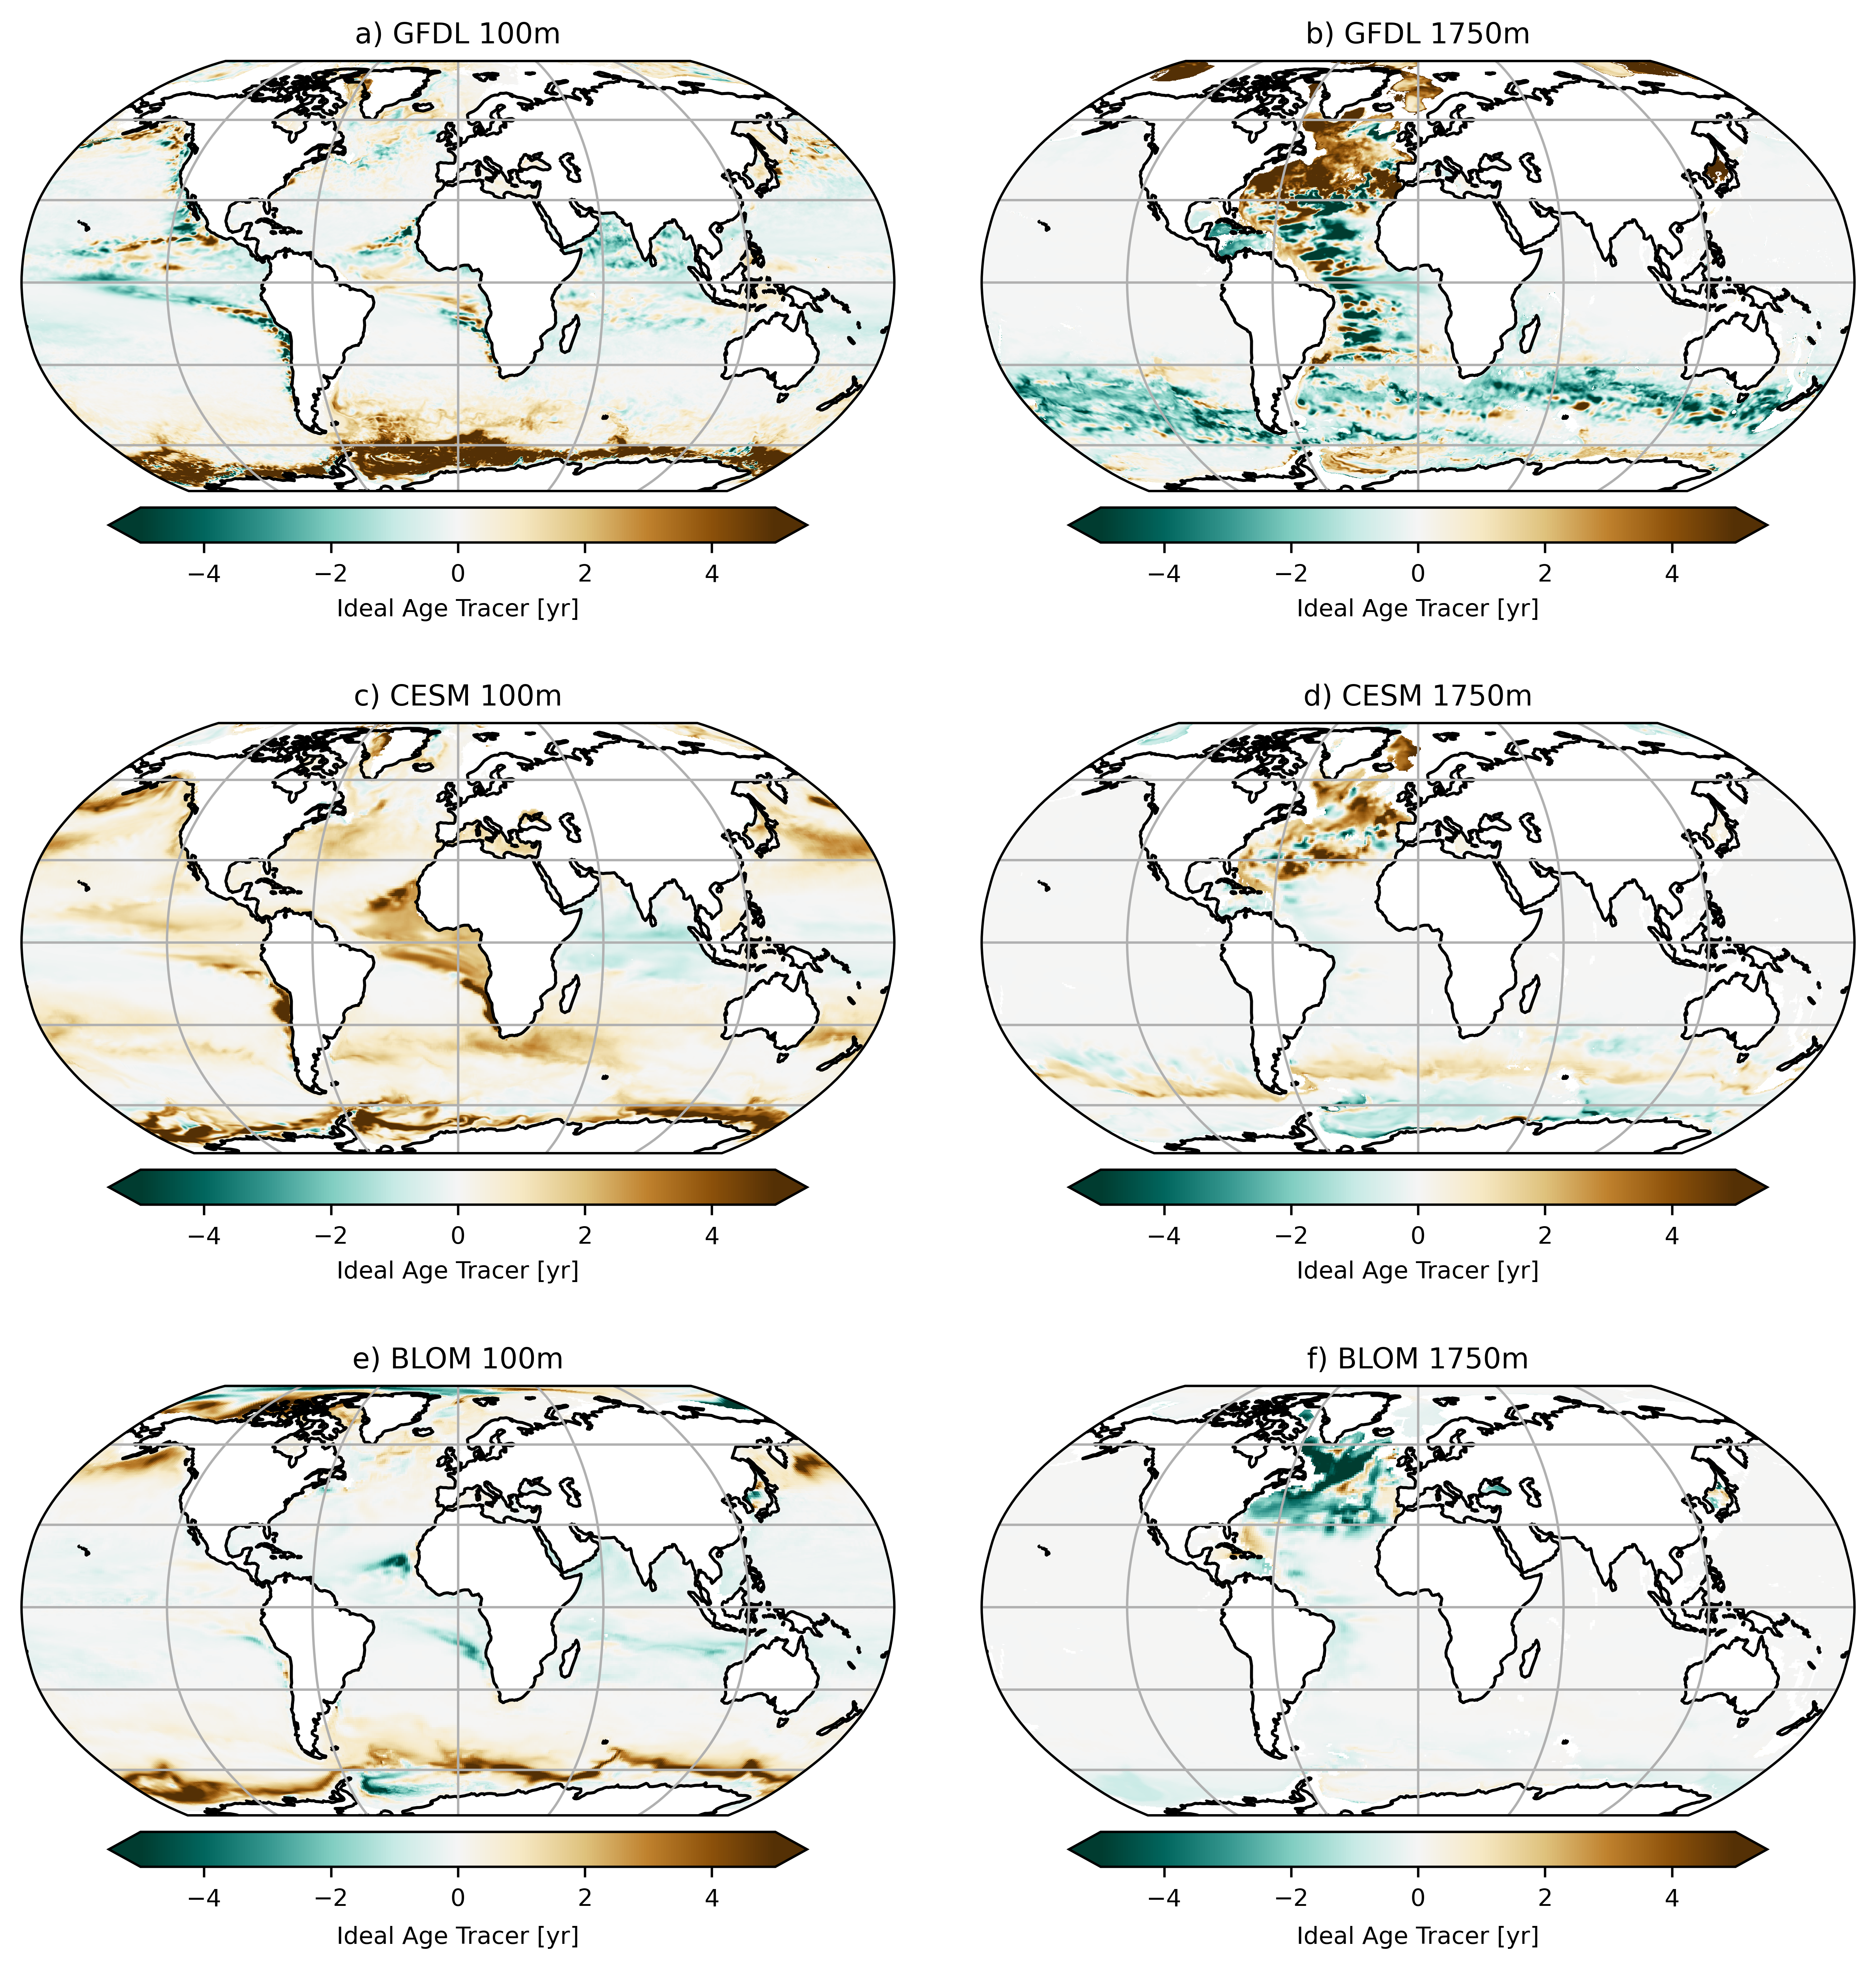

In [26]:
# create a figure
#fig = plt.figure()
fig, ax = plt.subplots(nrows=3,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=0)},
                        figsize=(11,13), dpi=600)


ax=ax.flatten()

cbar_lim = 5  

# ideal age BD minus FK - depth (100m) GFDL
i_ax = 0

(age_BD.isel(z_l=6) - age_FK.isel(z_l=6) ).rename('Ideal Age Tracer [yr]').plot(
    ax=ax[i_ax],
    transform=ccrs.PlateCarree(),  
    vmin=-cbar_lim,
    vmax=cbar_lim,          
    cmap="BrBG_r",  
    cbar_kwargs={'orientation': 'horizontal','pad': 0.02, 'shrink':0.8},
)
ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('a) GFDL 100m')


# ideal age BD minus FK - depth (1750m) GFDL
i_ax = 1
(age_BD.isel(z_l=24) - age_FK.isel(z_l=24) ).rename('Ideal Age Tracer [yr]').plot(
    ax=ax[i_ax],
    transform=ccrs.PlateCarree(),  
    vmin=-cbar_lim,
    vmax=cbar_lim,          
    cmap="BrBG_r", 
    cbar_kwargs={'orientation': 'horizontal','pad': 0.02, 'shrink':0.8},
)

ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('b) GFDL 1750m')



## CESM plots
# ideal age BD minus FK - depth (100m) CESM
i_ax = 2

(CESM_AGE_BOD23_100m.agessc - CESM_AGE_BFF11_100m.agessc).rename('Ideal Age Tracer [yr]').plot(
    ax=ax[i_ax],
    transform=ccrs.PlateCarree(),  
    vmin=-cbar_lim,
    vmax=cbar_lim,          
    cmap="BrBG_r",  
    cbar_kwargs={'orientation': 'horizontal','pad': 0.02, 'shrink':0.8},
)
ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('c) CESM 100m')


# ideal age BD minus FK - depth (1750m) CESM
i_ax = 3
((CESM_AGE_BOD23_1750m.agessc - CESM_AGE_BFF11_1750m.agessc)).rename('Ideal Age Tracer [yr]').plot(
    ax=ax[i_ax],
    transform=ccrs.PlateCarree(),  
    vmin=-cbar_lim,
    vmax=cbar_lim,          
    cmap="BrBG_r", 
    cbar_kwargs={'orientation': 'horizontal','pad': 0.02, 'shrink':0.8},
)

ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('d) CESM 1750m')




# ideal age BD minus FK - depth (100m) BLOM
i_ax = 4

tlon, tlat, data = enable_global(BLOM_grid.plon, BLOM_grid.plat,
                                 (BLOM_AGE_BOD23.ideal_age_100m - BLOM_AGE_BFF11.ideal_age_100m).rename('Ideal Age Tracer [yr]'))
im = ax[i_ax].pcolormesh(tlon, tlat, data,
                    transform=ccrs.PlateCarree(),  
                    vmin=-cbar_lim,
                    vmax=cbar_lim,          
                    cmap="BrBG_r")
              
ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('e) BLOM 100m')
cbar = plt.colorbar(im, ax=ax[i_ax],orientation= 'horizontal',pad= 0.02, shrink=0.8,extend='both')
cbar.set_label('Ideal Age Tracer [yr]', labelpad=5)

# ideal age BD minus FK - depth (1750m) BLOM
i_ax = 5
tlon, tlat, data = enable_global(BLOM_grid.plon, BLOM_grid.plat,
                                 (BLOM_AGE_BOD23.ideal_age_1750m - BLOM_AGE_BFF11.ideal_age_1750m).rename('Ideal Age Tracer [yr]'))
im = ax[i_ax].pcolormesh(tlon, tlat, data,
                    transform=ccrs.PlateCarree(),  
                    vmin=-cbar_lim,
                    vmax=cbar_lim,          
                    cmap="BrBG_r")
ax[i_ax].coastlines()
ax[i_ax].gridlines()
ax[i_ax].set_title('f) BLOM 1750m')
cbar = plt.colorbar(im, ax=ax[i_ax],orientation= 'horizontal',pad= 0.02, shrink=0.8,extend='both')
cbar.set_label('Ideal Age Tracer [yr]', labelpad=5)

plt.rcParams.update({'font.size': 8})
plt.subplots_adjust(wspace=0.1, hspace=-0.2)

# save figure
plt.savefig('./figures/ideal_age_all_models')
